In [7]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
df = pd.read_csv("Synthetic_Financial_datasets_log.csv")
print(f"Đọc thành công! Tổng số dòng: {df.shape[0]:,}, số cột: {df.shape[1]}")
df.head()

Đang đọc dữ liệu...
Đọc thành công! Tổng số dòng: 6,362,620, số cột: 11


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


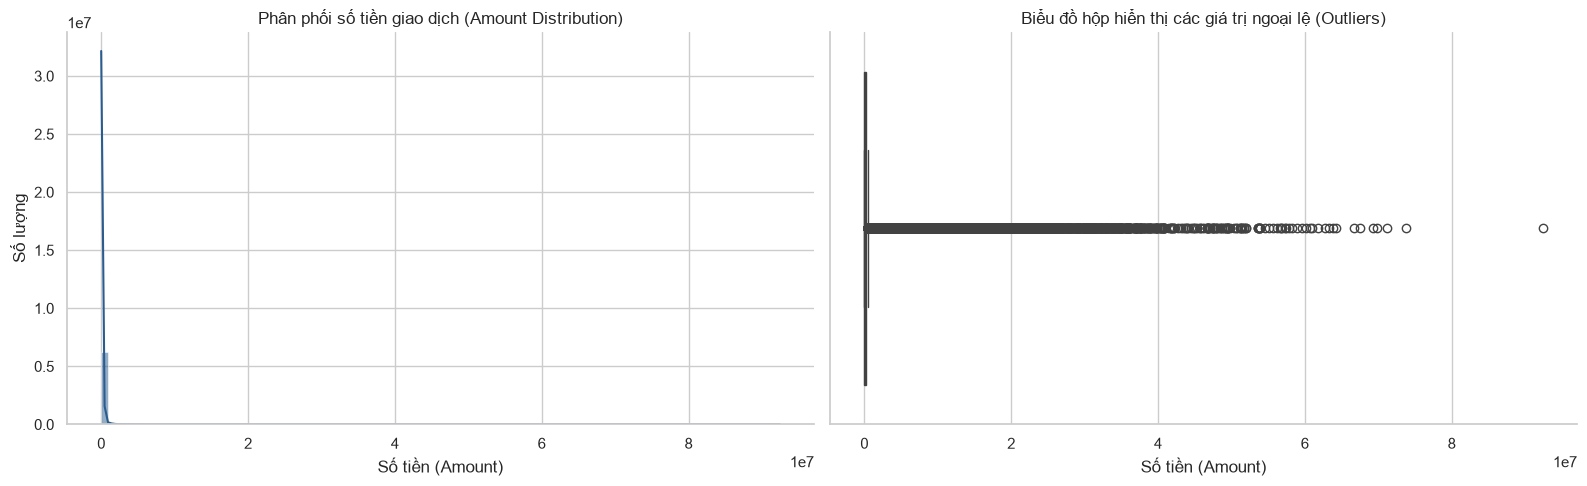

--- Thống kê Outliers ---
Ngưỡng xác định Outliers (Q3 + 1.5*IQR): 501,719.34
Số lượng giao dịch ngoại lệ: 338,078 (5.31%)
Số tiền giao dịch lớn nhất: 92,445,516.64


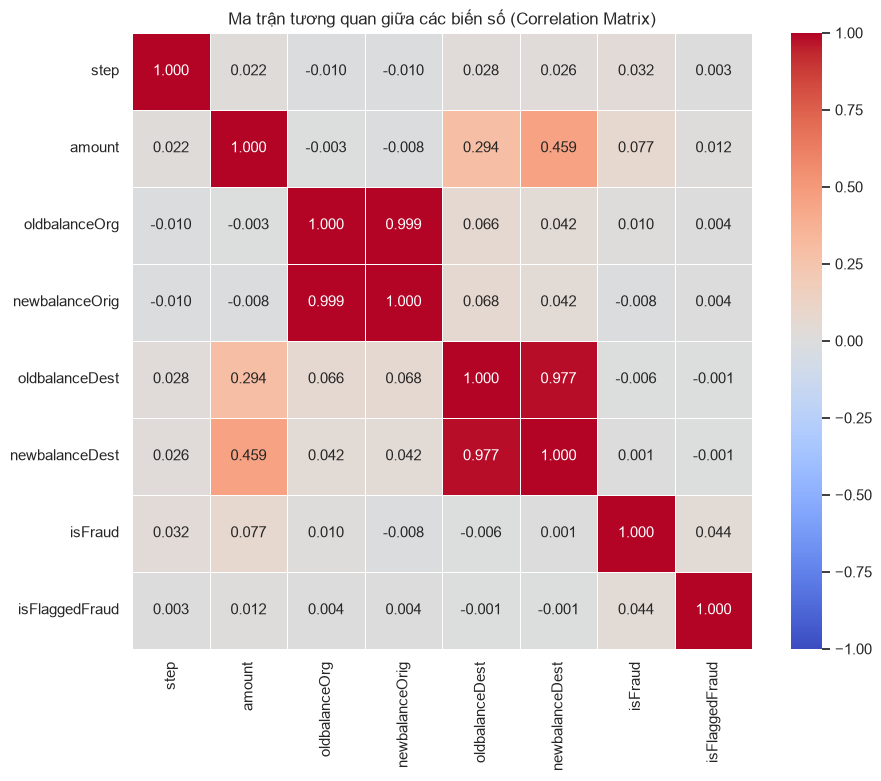

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['amount'], bins=100, kde=True, color='#2b5c8f', ax=axes[0])
axes[0].set_title("Phân phối số tiền giao dịch (Amount Distribution)")
axes[0].set_xlabel("Số tiền (Amount)")
axes[0].set_ylabel("Số lượng")

sns.boxplot(x=df['amount'], color='#d95f02', ax=axes[1])
axes[1].set_title("Biểu đồ hộp hiển thị các giá trị ngoại lệ (Outliers)")
axes[1].set_xlabel("Số tiền (Amount)")
plt.tight_layout()
plt.show()

q1 = df['amount'].quantile(0.25)
q3 = df['amount'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
outliers = df[df['amount'] > upper_bound]
print(f"--- Thống kê Outliers ---")
print(f"Ngưỡng xác định Outliers (Q3 + 1.5*IQR): {upper_bound:,.2f}")
print(f"Số lượng giao dịch ngoại lệ: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Số tiền giao dịch lớn nhất: {df['amount'].max():,.2f}")

numeric_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Ma trận tương quan giữa các biến số (Correlation Matrix)")
plt.show()

In [ ]:
fraud_counts = df['isFraud'].value_counts()
fraud_pct = df['isFraud'].value_counts(normalize=True) * 100
print("--- 1. Mất cân bằng lớp (Class Imbalance) ---")
print(f"Giao dịch thường (Non-Fraud): {fraud_counts[0]:,} dòng ({fraud_pct[0]:.4f}%)")
print(f"Giao dịch gian lận (Fraud):    {fraud_counts[1]:,} dòng ({fraud_pct[1]:.4f}%)")
print(f"Tỷ lệ mất cân bằng: 1 / {int(fraud_counts[0]/fraud_counts[1])}\n")

type_summary = df.groupby('type')['isFraud'].agg(['count', 'sum', 'mean']).reset_index()
type_summary.rename(columns={'count': 'Tổng giao dịch', 'sum': 'Số vụ gian lận', 'mean': 'Tỷ lệ gian lận'}, inplace=True)
type_summary['Tỷ lệ gian lận (%)'] = type_summary['Tỷ lệ gian lận'] * 100
print("--- 2. Tỷ lệ gian lận theo Loại giao dịch (Transaction Types) ---")
print(type_summary.to_string(index=False))
print("\n*Nhận xét: Toàn bộ các vụ gian lận chỉ xảy ra ở 2 loại giao dịch: TRANSFER và CASH_OUT.\n")

df['dest_type'] = df['nameDest'].str[0]
channel_summary = df.groupby('dest_type')['isFraud'].agg(['count', 'sum', 'mean']).reset_index()
channel_summary.rename(columns={'count': 'Tổng giao dịch', 'sum': 'Số vụ gian lận', 'mean': 'Tỷ lệ gian lận'}, inplace=True)
channel_summary['Tỷ lệ gian lận (%)'] = channel_summary['Tỷ lệ gian lận'] * 100
print("--- 3. Tỷ lệ gian lận theo Loại tài khoản nhận ---")
print(channel_summary.to_string(index=False))
print("\n*Nhận xét: Không có giao dịch gian lận nào được ghi nhận tới Merchant (M).\n")

df['hour_of_day'] = df['step'] % 24
hourly_summary = df.groupby('hour_of_day')['isFraud'].agg(['count', 'sum', 'mean']).reset_index()
hourly_summary.rename(columns={'count': 'Tổng giao dịch', 'sum': 'Số vụ gian lận', 'mean': 'Tỷ lệ gian lận'}, inplace=True)
hourly_summary['Tỷ lệ gian lận (%)'] = hourly_summary['Tỷ lệ gian lận'] * 100


--- 1. Mất cân bằng lớp (Class Imbalance) ---
Giao dịch thường (Non-Fraud): 6,354,407 dòng (99.8709%)
Giao dịch gian lận (Fraud):    8,213 dòng (0.1291%)
Tỷ lệ mất cân bằng: 1 / 773

--- 2. Tỷ lệ gian lận theo Loại giao dịch (Transaction Types) ---
    type  Tổng giao dịch  Số vụ gian lận  Tỷ lệ gian lận  Tỷ lệ gian lận (%)
 CASH_IN         1399284               0        0.000000            0.000000
CASH_OUT         2237500            4116        0.001840            0.183955
   DEBIT           41432               0        0.000000            0.000000
 PAYMENT         2151495               0        0.000000            0.000000
TRANSFER          532909            4097        0.007688            0.768799

*Nhận xét: Toàn bộ các vụ gian lận chỉ xảy ra ở 2 loại giao dịch: TRANSFER và CASH_OUT.

--- 3. Tỷ lệ gian lận theo Loại tài khoản nhận ---
dest_type  Tổng giao dịch  Số vụ gian lận  Tỷ lệ gian lận  Tỷ lệ gian lận (%)
        C         4211125            8213         0.00195            0

C:\Users\DatPhung\AppData\Local\Temp\ipykernel_11884\2175087083.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='isFraud', y='amount', data=df_filtered, palette='Set2')


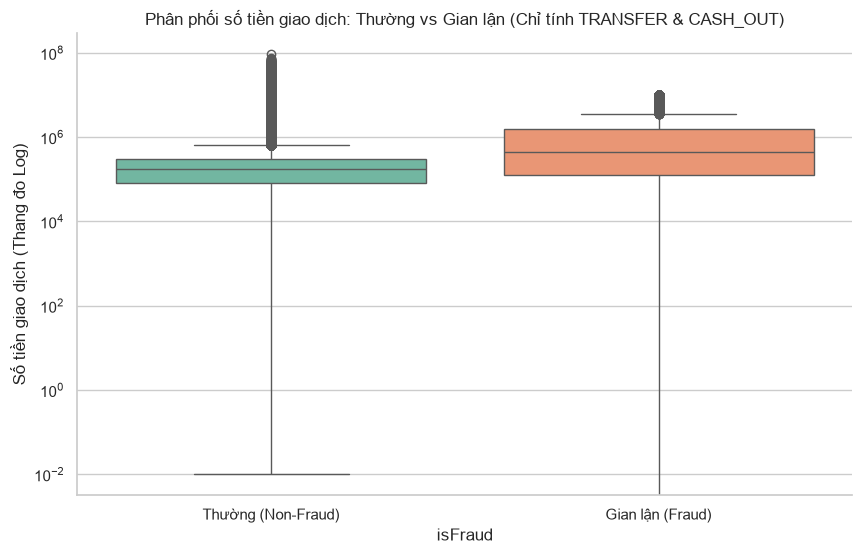

C:\Users\DatPhung\AppData\Local\Temp\ipykernel_11884\2175087083.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='type', y='Tỷ lệ gian lận (%)', data=type_summary, palette='viridis')


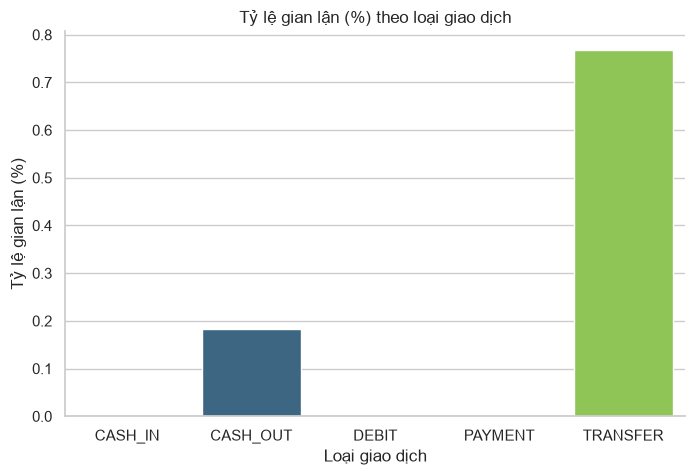

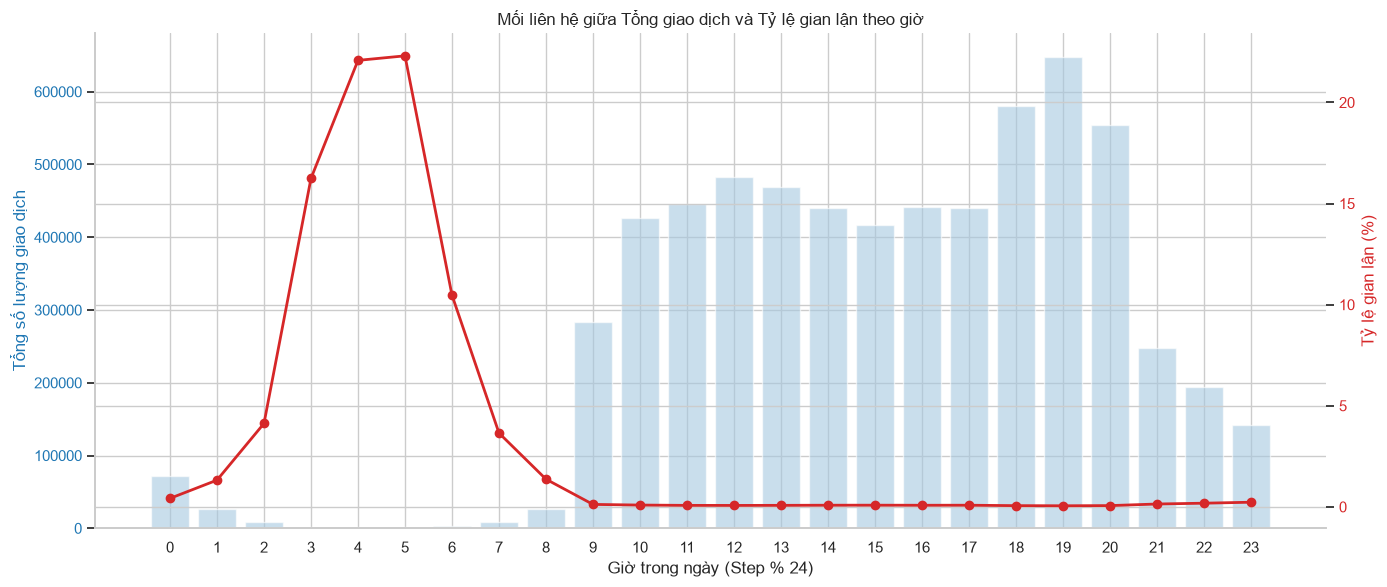

--- Tỷ lệ sai lệch số dư gốc (Balance Mismatch) ---
Tỷ lệ sai lệch ở giao dịch thường: 85.20%
Tỷ lệ sai lệch ở giao dịch gian lận: 1.55%


In [ ]:
plt.figure(figsize=(10, 6))
df_filtered = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]
sns.boxplot(x='isFraud', y='amount', data=df_filtered, palette='Set2')
plt.yscale('log')
plt.title("Phân phối số tiền giao dịch: Thường vs Gian lận (Chỉ tính TRANSFER & CASH_OUT)")
plt.xticks([0, 1], ['Thường (Non-Fraud)', 'Gian lận (Fraud)'])
plt.ylabel("Số tiền giao dịch (Thang đo Log)")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x='type', y='Tỷ lệ gian lận (%)', data=type_summary, palette='viridis')
plt.title("Tỷ lệ gian lận (%) theo loại giao dịch")
plt.ylabel("Tỷ lệ gian lận (%)")
plt.xlabel("Loại giao dịch")
plt.show()

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(hourly_summary['hour_of_day'], hourly_summary['Tổng giao dịch'], color='#a6c8e0', alpha=0.6, label='Tổng giao dịch')
ax1.set_xlabel('Giờ trong ngày (Step % 24)')
ax1.set_ylabel('Tổng số lượng giao dịch', color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_xticks(range(24))

ax2 = ax1.twinx()
ax2.plot(hourly_summary['hour_of_day'], hourly_summary['Tỷ lệ gian lận (%)'], color='#d62728', marker='o', linewidth=2, label='Tỷ lệ gian lận (%)')
ax2.set_ylabel('Tỷ lệ gian lận (%)', color='#d62728')
ax2.tick_params(axis='y', labelcolor='#d62728')

plt.title("Mối liên hệ giữa Tổng giao dịch và Tỷ lệ gian lận theo giờ")
fig.tight_layout()
plt.show()

df['errorBalanceOrig'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
df['is_mismatch_orig'] = (df['errorBalanceOrig'] != 0).astype(int)

mismatch_summary = df.groupby('isFraud')['is_mismatch_orig'].mean() * 100
print("--- Tỷ lệ sai lệch số dư gốc (Balance Mismatch) ---")
print(f"Tỷ lệ sai lệch ở giao dịch thường: {mismatch_summary[0]:.2f}%")
print(f"Tỷ lệ sai lệch ở giao dịch gian lận: {mismatch_summary[1]:.2f}%")
